 # Esercizio 2) Caso con $f: \mathbb{R}^2 \to \mathbb{R}$ non convessa

 Considerare la funzione di Rosenbrock
   $$
   f(x_1, x_2) = (1-x_1)^2   +  100(x_2-x_1^2)^2 
   $$
che ha minimo nel punto $x^* =(1,1)$.

Poi:
1. definire le funzioni python per `f` e `grad_f`;
2. calcolare il valore di $f(x^*)$ e verificare che $x^*$ è un punto stazionario di $f$;
3. visualizzare la superficie descritta da `f` nel dominio $[-2,5] \times [-3,5]$;
4. plottare la funzione fissando
    - $x_2 = 1$;
    - $x_2 = -1$;
    - $x_1 = 0$;
5. eseguire il metodo di discesa del gradiente con passo fisso, avendo definito 
    - $tol_{grad} = 1e-6$
    - maxit = 1000
    - $\alpha = \ 0.001 $ 
    - $x_0 = (2,2)$
    
    Provare i seguenti parametri 
    - maxit = 10000
    - $\alpha = \ 0.01 $ 
    - $x_0 = (-2, -2)$
    
    Per ogni prova, calcolare la distanza (errore in norma) fra la soluzione ottenuta e $x^*$.

6. eseguire il metodo di discesa del gradiente con backtracking e provare i parametri del punto 5

7. ripetere il metodo di discesa del gradiente con backtracking con parametri fissati $ maxit = 10000$, $\alpha_0 = 1 $ e $x_0 = (-2, -2)$, ma testare $tol_{grad} = 0.1,\ 0.001$



In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [28]:
#### punto 1 ########################

def f(x):
    x1, x2 = x

    return (1 - x1)**2 + 100 * (x2 - x1**2)**2

def grad_f(x):
    x1, x2 = x

    df_dx1 = 2 * (x1 - 1) - 400 * x1 * (x2 - x1**2)
    df_dx2 = 200 * (x2 - x1**2)

    return np.array([df_dx1, df_dx2])


In [29]:
#### punto 2 ########################

x_star = np.array( [1, 1])
print(f" f(x_star) = {f(x_star)} ")
print(f" Grad_f(x_star) = {grad_f(x_star)} ")

 f(x_star) = 0 
 Grad_f(x_star) = [0 0] 


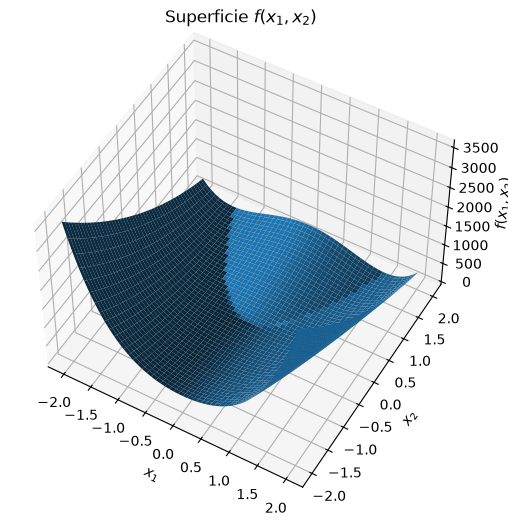

In [30]:
#### punto 3 ########################

# Costruzione della griglia
x1 = np.linspace(-2, 2, 200)
x2 = np.linspace(-2, 2, 200)
X1, X2 = np.meshgrid(x1, x2)

# Valutazione della funzione
Y = f( (X1,X2) )

# Grafico della superficie
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, Y)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_zlabel("$f(x_1,x_2)$")
ax.set_title(r"Superficie $f(x_1,x_2)$")

ax.view_init(elev=50, azim=-60)
# ax.view_init(elev=90, azim=-90)
# ax.view_init(elev=5, azim=90)

plt.show()

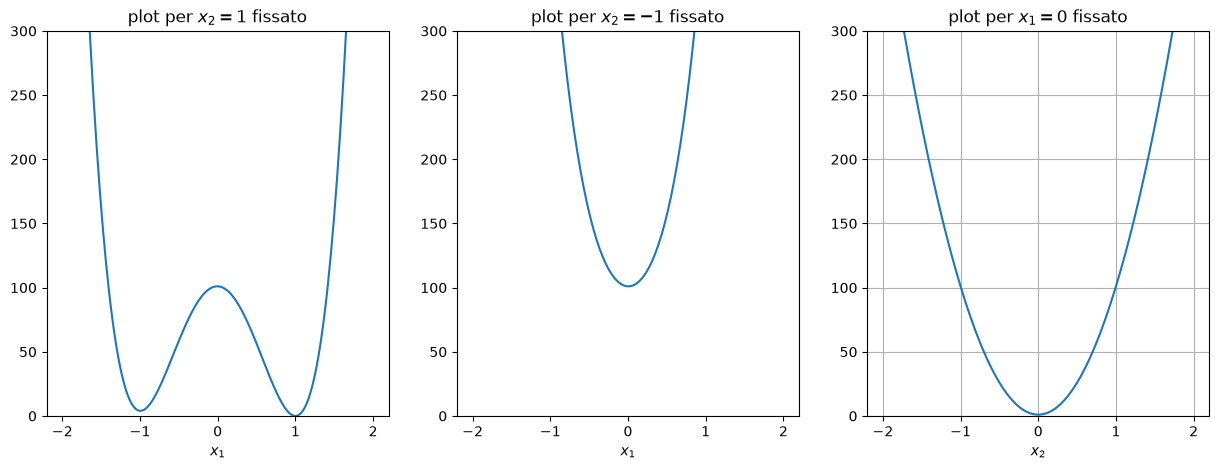

In [24]:
#### punto 4 ########################

y_a = f( (x1,1) )
y_b = f( (x1,-1) )
y_c = f( (0,x2) )

# Visualizzo
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(x1, y_a)
plt.title('plot per $x_2=1$ fissato')
plt.xlabel('$x_1$')
plt.ylim( (0, 300))

plt.subplot(1, 3, 2)
plt.plot(x1, y_b)
plt.title('plot per $x_2=-1$ fissato')
plt.xlabel('$x_1$')
plt.ylim( (0, 300))

plt.subplot(1, 3, 3)
plt.plot(x2, y_c)
plt.title('plot per $x_1=0$ fissato')
plt.xlabel('$x_2$')
plt.ylim( (0, 300))

plt.grid()
plt.show()

In [58]:
#### punto 5 ########################

def discesa_gradiente(
    f,              # funzione obiettivo
    grad_f,         # gradiente della funzione obiettivo
    x0,             # punto iniziale 
    alpha=1.0,      # lunghezza del passo, alpha>0
    tol_grad=1e-6,  # tolleranza sulla norma del gradiente
    maxit=1000      # massimo numero di iterazioni
):
    """
    Discesa del gradiente con passo fisso.
    """

    # Inizializzazioni
    x = np.asarray(x0, dtype=float).copy()

    k = 0
    fx = f(x)
    grad = grad_f(x)
    grad_norm = np.linalg.norm(grad)

    history = {
        "x": [x.copy()],
        "f": [fx],
        "grad_norm": [grad_norm]
    }

    # Ciclo iterativo di risoluzione
    while grad_norm > tol_grad and k < maxit:

        # Direzione di discesa
        p = -grad

        # Aggiornamento dell'iterata
        x = x + alpha * p
        k += 1

        # Aggiornamento delle quantità
        fx = f(x)
        grad = grad_f(x)
        grad_norm = np.linalg.norm(grad)

        # Salvataggio della storia
        history["x"].append(x.copy())
        history["f"].append(fx)
        history["grad_norm"].append(grad_norm)

    if grad_norm <= tol_grad:  # x è punto stazionario
        print(f"Convergenza numerica raggiunta in {k} iterazioni.")
    else:
        print("Raggiunto il numero massimo di iterazioni.")

    return x, history


x_start = np.array( [2,2] )
maxiter = 1000
passo = 0.001

x_sol, hist = discesa_gradiente(f, grad_f, x0=x_start, maxit=maxiter, alpha=passo)

Raggiunto il numero massimo di iterazioni.


In [59]:
print(x_sol)

errore = np.linalg.norm(x_star-x_sol)
print(f"Errore della soluzione: {errore}")

[1.20924655 1.46301622]
Errore della soluzione: 0.5081024912438226


In [64]:
#### punto 6 ########################

def discesa_gradiente_bt(
    f,              # funzione obiettivo
    grad_f,         # gradiente della funzione obiettivo
    x0,             # punto iniziale 
    alpha0=1.0,     # lunghezza del passo iniziale, 0<alpha
    rho=0.5,        # fattore di riduzione del passo, 0<rho<1
    c1=1e-4,        # parametro della condizione di Armijo, 0<c1<1
    tau=1e-12,      # lunghezza del minimo passo ammesso, 0<rho<alpha
    tol_grad=1e-6,  # tolleranza sulla norma del gradiente
    maxit=1000      # massimo numero di iterazioni
):
    """
    Discesa del gradiente con backtracking di Armijo.
    """

    # Controlli sugli imput
    if not 0 < rho < 1:
        raise ValueError("rho deve appartenere a (0, 1).")

    if not 0 < c1 < 1:
        raise ValueError("c1 deve appartenere a (0, 1).")

    if not 0 < tau <= alpha0:
        raise ValueError("tau deve essere positivo e non superiore ad alpha0.")

    # Inizializzazioni
    x = np.asarray(x0, dtype=float).copy()

    k = 0
    fx = f(x)
    grad = grad_f(x)
    grad_norm = np.linalg.norm(grad)

    history = {
        "x": [x.copy()],
        "f": [fx],
        "grad_norm": [grad_norm],
        "alpha": []
    }

    # Ciclo iterativo di risoluzione
    while grad_norm > tol_grad and k < maxit:

        # Direzione di discesa
        p = -grad

        # Scelta del passo di discesa
        alpha = alpha0

        while f(x + alpha * p) > fx + c1 * alpha * np.dot(grad, p): # Backtracking di Armijo

            if alpha <= tau:
                print("Passo minimo raggiunto senza soddisfare Armijo.")
                return x, history

            alpha = max(rho * alpha, tau)

        # Aggiornamento dell'iterata
        x = x + alpha * p
        k += 1

        # Aggiornamento delle quantità
        fx = f(x)
        grad = grad_f(x)
        grad_norm = np.linalg.norm(grad)

        # Salvataggio della storia
        history["x"].append(x.copy())
        history["f"].append(fx)
        history["grad_norm"].append(grad_norm)
        history["alpha"].append(alpha)

    if grad_norm <= tol_grad:  # x è punto stazionario
        print(f"Convergenza numerica raggiunta in {k} iterazioni.")
    else:
        print("Raggiunto il numero massimo di iterazioni.")

    return x, history


x_start = np.array( [-2,-2] )
maxiter = 10000
alpha_start = 1

x_sol, hist = discesa_gradiente_bt(f, grad_f, x0=x_start, maxit=maxiter, alpha0=alpha_start)
print(x_sol)

errore = np.linalg.norm(x_star-x_sol)
print(f"Errore della soluzione: {errore}")

Raggiunto il numero massimo di iterazioni.
[1.00020831 1.00041639]
Errore della soluzione: 0.0004655863979908432


In [68]:
#### punto 7 ########################

x_start = np.array( [-2,-2] )
maxiter = 10000
alpha_start = 1
tol = 0.01

x_sol, hist = discesa_gradiente_bt(f, grad_f, x0=x_start, maxit=maxiter, alpha0=alpha_start, tol_grad=tol)
print(x_sol)

errore = np.linalg.norm(x_star-x_sol)
print(f"Errore della soluzione: {errore}")

Convergenza numerica raggiunta in 5501 iterazioni.
[1.00772751 1.01556155]
Errore della soluzione: 0.01737458872006766
